# Estudo de ablação — sMCI vs pMCI (hipocampo L/R × T1/T2/T3)

Compara três modalidades de features com o **mesmo protocolo** de validação cruzada aninhada (5×5):

| ID | Arquivo | Conteúdo |
|----|---------|----------|
| `all` | `feat_merge_all_hipp.csv` | radiomics + displacement |
| `rad` | `feat_rad_all_hipp.csv` | radiomics |
| `disp` | `feat_disp_all_hipp.csv` | displacement |

**Pré-processamento dentro de cada fold** (sem vazamento):
1. Filtro de correlação (|r| > 0,90)
2. Filtro de variância (< 0,01)
3. MRMR por bloco `(L/R, T1/T2/T3)` — K features por bloco *(modo `mrmr`)*
4. StandardScaler → classificador

Compare modos via `SELECTION_MODES`:
- **`mrmr`**: correlação + variância + MRMR por bloco
- **`filters`**: correlação + variância, sem MRMR
- **`raw`**: todas as features brutas, sem seleção

CV externo e interno estratificados por GROUP.

Modelos: SVM, Random Forest, XGBoost, MLP. O `GridSearchCV` interno otimiza apenas hiperparâmetros do classificador.

In [ ]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, roc_curve,
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

try:
    from feature_engine.selection import MRMR
    HAS_MRMR = True
except ImportError:
    HAS_MRMR = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
K_OUT, K_IN = 5, 5
K_PER_BLOCK = 4
META_COLS = ["ID_PT", "GROUP", "SEX"]
GROUP_LABELS = {0: "sMCI", 1: "pMCI"}
SEX_LABELS = {0: "M", 1: "F"}
BASE_DIR = Path("csvs/abordagem_4_sMCI_pMCI_extremos")
RESULTS_PATH = BASE_DIR / "ablation_results_onlyrad_delta_filtered.csv"
SUMMARY_PATH = BASE_DIR / "ablation_summary_onlyrad_delta_filtered.csv"

# Modos de seleção de atributos para comparar abordagens
SELECTION_MODES = {
    "mrmr": {
        "use_mrmr": True,
        "use_filters": True,
        "label": "corr + var + MRMR",
    },
    "filters": {
        "use_mrmr": False,
        "use_filters": True,
        "label": "corr + var (sem MRMR)",
    },
    "raw": {
        "use_mrmr": False,
        "use_filters": False,
        "label": "sem seleção",
    },
}
# Rode um ou mais modos na célula de execução, ex.: ["mrmr", "filters"]
RUN_SELECTION_MODES = ["mrmr"]#["raw", "mrmr", "filters"]

METRIC_COLS = [
    "accuracy", "auc", "auc_pr", "bal_acc", "mcc",
    "sens_pMCI", "spec_sMCI", "f1_pMCI",
]

ABLATION_CONFIGS = {
    "all": {
        "path": BASE_DIR / "feat_rad_all_hipp_delta_filtered.csv",
        "label": "merge (rad + disp)",
    },
    # "rad": {
    #     "path": BASE_DIR / "feat_rad_all_hipp_notext_filtered.csv",
    #     "label": "radiomics",
    # },
    # "disp": {
    #     "path": BASE_DIR / "feat_disp_all_hipp_filtered.csv",
    #     "label": "displacement",
    # },
}

MODELS = ["svm", "rf", "mlp"] #, "xgb", "mlp"]

if not HAS_MRMR:
    raise ImportError(
        "Instale feature-engine: pip install feature-engine"
    )

In [22]:
BLOCK_RE = re.compile(r"hippocampus_([LR])_(T[123])_")


def normalize_sex(sex: np.ndarray) -> np.ndarray:
    """Codifica sexo como 0=M, 1=F (aceita M/F ou 0/1)."""
    s = np.asarray(sex)
    if s.dtype == object or str(s.dtype) == "string":
        return np.where(np.isin(s, ["F", "f", 1, "1"]), 1, 0).astype(int)
    return s.astype(int)


def group_sex_stratum(y: np.ndarray, sex: np.ndarray) -> np.ndarray:
    """Rótulo combinado para estratificação: 0=sMCI_M … 3=pMCI_F."""
    return y.astype(int) * 2 + normalize_sex(sex)


def stratum_crosstab(y: np.ndarray, sex: np.ndarray) -> pd.DataFrame:
    group_lab = pd.Series(y).map(GROUP_LABELS)
    sex_lab = pd.Series(normalize_sex(sex)).map(SEX_LABELS)
    return pd.crosstab(group_lab, sex_lab)


def print_split_stratification(
    y: np.ndarray,
    sex: np.ndarray,
    indices: np.ndarray,
    split_name: str,
) -> None:
    yi, si = y[indices], sex[indices]
    tab = stratum_crosstab(yi, si)
    print(f"  {split_name} (n={len(indices)}):")
    print(tab.to_string(header=True))
    print(
        f"    GROUP: sMCI={(yi == 0).sum()} pMCI={(yi == 1).sum()} | "
        f"SEX: M={(normalize_sex(si) == 0).sum()} F={(normalize_sex(si) == 1).sum()}"
    )


def print_fold_stratification(
    y: np.ndarray,
    sex: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    fold: int,
    modality: str,
) -> None:
    print(f"\n{'=' * 60}")
    print(f"[{modality}] Fold externo {fold}")
    print_split_stratification(y, sex, train_idx, "TREINO")
    print_split_stratification(y, sex, test_idx, "TESTE")
    y_tr = y[train_idx]
    min_class = int(min((y_tr == 0).sum(), (y_tr == 1).sum()))
    print(
        f"  Após undersampling GROUP (só treino): "
        f"n={min_class * 2} ({min_class} por classe)"
    )


def print_cv_stratification_summary(
    modality: str,
    y: np.ndarray,
    sex: np.ndarray,
    n_splits: int = K_OUT,
) -> None:
    print(f"\n{'#' * 60}")
    print(f"Estratificação por fold — modalidade {modality.upper()}")
    print(f"{'#' * 60}")
    print("Cohorte completa:")
    print(stratum_crosstab(y, sex).to_string())
    print(
        f"  TOTAL: n={len(y)} | sMCI={(y == 0).sum()} pMCI={(y == 1).sum()} | "
        f"M={(normalize_sex(sex) == 0).sum()} F={(normalize_sex(sex) == 1).sum()}"
    )
    outer_cv = StratifiedKFold(n_splits, shuffle=True, random_state=SEED)
    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(np.zeros(len(y)), y), start=1
    ):
        print_fold_stratification(y, sex, train_idx, test_idx, fold, modality)


def block_key(col: str) -> tuple[str, str] | None:
    m = BLOCK_RE.search(col)
    return (m.group(1), m.group(2)) if m else None

# testar: corr_threshold: [0.85, 0.90, 0.95]
def corr_keep_mask(X: np.ndarray, threshold: float = 0.90) -> np.ndarray:
    """Máscara booleana de colunas a manter após filtro de correlação."""
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    n = xf.shape[1]
    if xf.shape[0] < 2:
        return np.ones(n, dtype=bool)
    c = np.corrcoef(xf.T)
    keep_idx = []
    for j in range(n):
        if all(
            not (np.isfinite(c[j, k]) and abs(c[j, k]) > threshold)
            for k in keep_idx
        ):
            keep_idx.append(j)
    mask = np.zeros(n, dtype=bool)
    mask[keep_idx] = True
    return mask

# testar: var_threshold: [0.001, 0.01, 0.05]
def var_keep_mask(X: np.ndarray, threshold: float = 0.01) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return np.var(xf, axis=0) >= threshold


def mrmr_by_block(
    df: pd.DataFrame,
    y: np.ndarray,
    max_per_block: int = K_PER_BLOCK,
    method: str = "FCQ",
) -> list[str]:
    """Seleciona até K features por bloco (L/R × T1/T2/T3) via MRMR."""
    selected: list[str] = []
    blocks: dict[tuple[str, str], list[str]] = {}
    for col in df.columns:
        key = block_key(col)
        if key is not None:
            blocks.setdefault(key, []).append(col)

    for key in sorted(blocks):
        cols = blocks[key]
        k = min(max_per_block, len(cols))
        if k == 0:
            continue
        if k >= len(cols):
            selected.extend(cols)
            continue
        sel = MRMR(
            variables=cols,
            method=method,
            max_features=k,
        ).fit(df[cols], y)
        selected.extend(list(sel.get_feature_names_out()))
    return selected


class CorrVarMRMRByBlock(BaseEstimator, TransformerMixin):
    """Pré-seleção ajustada apenas no treino do fold.

    Modos (via `use_mrmr` / `use_filters`):
    - corr + var + MRMR por bloco (padrão)
    - corr + var, sem MRMR (`use_mrmr=False`)
    - sem seleção (`use_filters=False`, `use_mrmr=False`)
    """

    def __init__(
        self,
        corr_threshold: float = 0.90,
        var_threshold: float = 1e-9,#0.01,
        k_per_block: int = K_PER_BLOCK,
        mrmr_method: str = "FCQ",
        use_mrmr: bool = True,
        use_filters: bool = True,
    ):
        self.corr_threshold = corr_threshold
        self.var_threshold = var_threshold
        self.k_per_block = k_per_block
        self.mrmr_method = mrmr_method
        self.use_mrmr = use_mrmr
        self.use_filters = use_filters

    def _as_frame(self, X) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            return X.copy()
        if hasattr(self, "feature_names_in_"):
            return pd.DataFrame(X, columns=self.feature_names_in_)
        raise TypeError("X deve ser DataFrame com nomes de colunas.")

    def fit(self, X, y=None):
        df_in = self._as_frame(X)
        self.feature_names_in_ = list(df_in.columns)
        names = list(df_in.columns)
        X_arr = df_in.to_numpy(dtype=float)

        if self.use_filters:
            corr_mask = corr_keep_mask(X_arr, self.corr_threshold)
            names = [n for n, keep in zip(names, corr_mask) if keep]
            X_arr = X_arr[:, corr_mask]

            var_mask = var_keep_mask(X_arr, self.var_threshold)
            names = [n for n, keep in zip(names, var_mask) if keep]
            X_arr = X_arr[:, var_mask]

        if X_arr.shape[1] == 0:
            self.selected_indices_ = np.array([], dtype=int)
            self.selected_names_ = []
            return self

        if self.use_mrmr:
            df = pd.DataFrame(X_arr, columns=names)
            selected_names = mrmr_by_block(
                df, y, max_per_block=self.k_per_block, method=self.mrmr_method
            )
            if not selected_names:
                selected_names = names[: min(10, len(names))]
        else:
            selected_names = names

        name_to_idx = {n: i for i, n in enumerate(self.feature_names_in_)}
        self.selected_names_ = selected_names
        self.selected_indices_ = np.array(
            [name_to_idx[n] for n in selected_names], dtype=int
        )
        return self

    def transform(self, X):
        df_in = self._as_frame(X)
        X_arr = df_in[self.feature_names_in_].to_numpy(dtype=float)
        if self.selected_indices_.size == 0:
            raise ValueError("Nenhuma feature selecionada após pré-filtros.")
        return X_arr[:, self.selected_indices_]


def load_modality(
    modality: str,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str], pd.DataFrame]:
    cfg = ABLATION_CONFIGS[modality]
    df = pd.read_csv(cfg["path"])
    feature_cols = [c for c in df.columns if c not in META_COLS]
    X = df[feature_cols].astype(float)
    y = df["GROUP"].to_numpy(dtype=int)
    sex = df["SEX"].to_numpy()
    return X, y, sex, feature_cols, df


def fold_metrics(y_true, scores, pred) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "auc": float(roc_auc_score(y_true, scores)),
        "auc_pr": float(average_precision_score(y_true, scores)),
        "bal_acc": float(balanced_accuracy_score(y_true, pred)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "sens_pMCI": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "spec_sMCI": float(tn / (tn + fp)) if (tn + fp) else 0.0,
        "f1_pMCI": float(f1_score(y_true, pred, pos_label=1, zero_division=0)),
    }


def tune_youden_threshold(y_true, scores) -> float:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, scores)
    return float(thr[int(np.argmax(tpr - fpr))])


def get_scores(model, X):
    clf = model.named_steps["clf"]
    if hasattr(clf, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def count_features_after_preprocess(model, X):
    Xt = X
    for name, step in model.steps[:-1]:
        if hasattr(step, "transform") and name != "sampler":
            Xt = step.transform(Xt)
    return int(Xt.shape[1])

In [23]:
PARAM_GRIDS = {
    "svm": {
        "preselect__k_per_block": [2, 4, 6],
        "clf": [SVC(probability=True, class_weight="balanced", random_state=SEED)],
        "clf__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__gamma": ["scale", "auto"],
        "clf__kernel": ["rbf", "linear"],
    },
    "rf": {
        "preselect__k_per_block": [2, 4, 6],
        "clf": [RandomForestClassifier(class_weight="balanced", random_state=SEED)],
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10, None],
        "clf__min_samples_split": [2, 5],
    },
    "xgb": {
        "preselect__k_per_block": [2, 4, 6],
        "clf": [XGBClassifier(eval_metric="logloss", random_state=SEED)],
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1],
        "clf__max_depth": [3, 5],
    },
    "mlp": {
        "preselect__k_per_block": [2, 4, 6],
        "clf": [MLPClassifier(
            activation="relu", alpha=1e-3, batch_size=32,
            learning_rate="adaptive", max_iter=400, early_stopping=True,
            validation_fraction=0.15, random_state=SEED,
        )],
        "clf__hidden_layer_sizes": [(64, 32), (32,), (16,)],
        "clf__alpha": [1e-4, 1e-3, 1e-2]
    },
}


def param_grid_for(model_key: str, selection_mode: str) -> dict:
    """K por bloco só entra no grid quando MRMR está ativo."""
    return {
        k: v
        for k, v in PARAM_GRIDS[model_key].items()
        if k != "preselect__k_per_block" or selection_mode == "mrmr"
    }


def make_pipeline(selection_mode: str = "mrmr") -> ImbPipeline:
    cfg = SELECTION_MODES[selection_mode]
    return ImbPipeline([
        ("preselect", CorrVarMRMRByBlock(
            use_mrmr=cfg["use_mrmr"],
            use_filters=cfg["use_filters"],
        )),
        ("scaler", StandardScaler()),
        # ("sampler", RandomUnderSampler(random_state=SEED)),
        ("clf", SVC(random_state=SEED)),
    ])


def nested_cv_ablation(
    X: pd.DataFrame,
    y: np.ndarray,
    sex: np.ndarray,
    model_key: str,
    modality: str,
    selection_mode: str = "mrmr",
    print_stratification: bool = True,
) -> pd.DataFrame:
    results = []
    test_name = f"ablation_{selection_mode}_{modality}_{model_key}"
    base_pipeline = make_pipeline(selection_mode)
    outer_cv = StratifiedKFold(K_OUT, shuffle=True, random_state=SEED)

    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X, y), start=1
    ):
        if print_stratification:
            print_fold_stratification(
                y, sex, train_idx, test_idx, fold, modality
            )

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        inner_cv = StratifiedKFold(
            K_IN, shuffle=True, random_state=SEED + fold
        )

        grid_search = GridSearchCV(
            base_pipeline,
            param_grid_for(model_key, selection_mode),
            cv=inner_cv,
            scoring="roc_auc",
            n_jobs=-1,
            refit=True,
        )
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        clf_name = best_model.named_steps["clf"].__class__.__name__
        preselect = best_model.named_steps["preselect"]
        selected_features = list(preselect.selected_names_)

        method = (
            "predict_proba"
            if hasattr(best_model.named_steps["clf"], "predict_proba")
            else "decision_function"
        )
        train_scores = cross_val_predict(
            best_model, X_train, y_train, cv=inner_cv, method=method
        )
        if method == "predict_proba":
            train_scores = train_scores[:, 1]

        threshold = tune_youden_threshold(y_train, train_scores)
        test_scores = get_scores(best_model, X_test)
        test_preds = (test_scores >= threshold).astype(int)

        row = {
            "test": test_name,
            "selection_mode": selection_mode,
            "selection_label": SELECTION_MODES[selection_mode]["label"],
            "modality": modality,
            "modality_label": ABLATION_CONFIGS[modality]["label"],
            "model_key": model_key,
            "fold": fold,
            "best_model": clf_name,
            "best_inner_auc": float(grid_search.best_score_),
            "best_params": json.dumps(grid_search.best_params_, default=str),
            "threshold": threshold,
            "n_features_raw": X.shape[1],
            "n_features_selected": count_features_after_preprocess(
                best_model, X_train
            ),
            "n_train_balanced": int(
                min((y_train == 0).sum(), (y_train == 1).sum()) * 2
            ),
            "selected_features": json.dumps(selected_features),
            **fold_metrics(y_test, test_scores, test_preds),
        }
        results.append(row)
        print(
            f"[{selection_mode}/{modality}/{model_key}] Fold {fold} | {clf_name:22s} | "
            f"feat={row['n_features_selected']:3d} | "
            f"AUC inner={row['best_inner_auc']:.3f} | AUC test={row['auc']:.3f}"
        )

    return pd.DataFrame(results)

In [24]:
# Visão geral dos dados por modalidade + estratificação GROUP×SEX por fold
for mod, cfg in ABLATION_CONFIGS.items():
    X, y, sex, cols, _ = load_modality(mod)
    n_blocks = len({block_key(c) for c in cols if block_key(c)})
    print(
        f"{mod:5s} | {cfg['label']:22s} | "
        f"{X.shape[0]} pacientes | {X.shape[1]} features | "
        f"{n_blocks} blocos L/R×T | sMCI={(y==0).sum()} pMCI={(y==1).sum()} | "
        f"M={(normalize_sex(sex)==0).sum()} F={(normalize_sex(sex)==1).sum()}"
    )
    print("  GROUP × SEX:")
    print(stratum_crosstab(y, sex).to_string(header=True))
    print_cv_stratification_summary(mod, y, sex)

all   | merge (rad + disp)     | 525 pacientes | 468 features | 0 blocos L/R×T | sMCI=397 pMCI=128 | M=303 F=222
  GROUP × SEX:
col_0    F    M
row_0          
pMCI    54   74
sMCI   168  229

############################################################
Estratificação por fold — modalidade ALL
############################################################
Cohorte completa:
col_0    F    M
row_0          
pMCI    54   74
sMCI   168  229
  TOTAL: n=525 | sMCI=397 pMCI=128 | M=303 F=222

[all] Fold externo 1
  TREINO (n=420):
col_0    F    M
row_0          
pMCI    42   60
sMCI   131  187
    GROUP: sMCI=318 pMCI=102 | SEX: M=247 F=173
  TESTE (n=105):
col_0   F   M
row_0        
pMCI   12  14
sMCI   37  42
    GROUP: sMCI=79 pMCI=26 | SEX: M=56 F=49
  Após undersampling GROUP (só treino): n=204 (102 por classe)

[all] Fold externo 2
  TREINO (n=420):
col_0    F    M
row_0          
pMCI    47   55
sMCI   136  182
    GROUP: sMCI=318 pMCI=102 | SEX: M=237 F=183
  TESTE (n=105):
col_0   F   

In [25]:
# Execução completa: modos de seleção × 3 modalidades × modelos
all_results: list[pd.DataFrame] = []

for selection_mode in RUN_SELECTION_MODES:
    print(f"\n{'#' * 60}")
    print(
        f"MODO DE SELEÇÃO: {selection_mode.upper()} — "
        f"{SELECTION_MODES[selection_mode]['label']}"
    )
    print(f"{'#' * 60}")

    for modality in ABLATION_CONFIGS:
        X, y, sex, feature_cols, _ = load_modality(modality)
        print(f"\n{'='*60}")
        print(f"MODALIDADE: {modality.upper()} — {ABLATION_CONFIGS[modality]['label']}")
        print(f"{'='*60}")
        print_cv_stratification_summary(modality, y, sex)

        for model_key in MODELS:
            print(f"\n--- {model_key.upper()} ---")
            df_run = nested_cv_ablation(
                X, y, sex, model_key, modality,
                selection_mode=selection_mode,
                print_stratification=False,
            )
            all_results.append(df_run)

df_ablation = pd.concat(all_results, ignore_index=True)
df_ablation.to_csv(RESULTS_PATH, index=False)
print(f"\nResultados salvos em: {RESULTS_PATH}")
df_ablation.head()


############################################################
MODO DE SELEÇÃO: MRMR — corr + var + MRMR
############################################################

MODALIDADE: ALL — merge (rad + disp)

############################################################
Estratificação por fold — modalidade ALL
############################################################
Cohorte completa:
col_0    F    M
row_0          
pMCI    54   74
sMCI   168  229
  TOTAL: n=525 | sMCI=397 pMCI=128 | M=303 F=222

[all] Fold externo 1
  TREINO (n=420):
col_0    F    M
row_0          
pMCI    42   60
sMCI   131  187
    GROUP: sMCI=318 pMCI=102 | SEX: M=247 F=173
  TESTE (n=105):
col_0   F   M
row_0        
pMCI   12  14
sMCI   37  42
    GROUP: sMCI=79 pMCI=26 | SEX: M=56 F=49
  Após undersampling GROUP (só treino): n=204 (102 por classe)

[all] Fold externo 2
  TREINO (n=420):
col_0    F    M
row_0          
pMCI    47   55
sMCI   136  182
    GROUP: sMCI=318 pMCI=102 | SEX: M=237 F=183
  TESTE (n=105):
c

,test,selection_mode,selection_label,modality,modality_label,model_key,fold,best_model,best_inner_auc,best_params,...,n_train_balanced,selected_features,accuracy,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,f1_pMCI
0,ablation_mrmr_all_svm,mrmr,corr + var + MRMR,all,merge (rad + disp),svm,1,SVC,0.641904,"{""clf"": ""SVC(class_weight='balanced', probabil...",...,204,"[""hippocampus_L_d12_ICV_mask_mm3"", ""hippocampu...",0.580952,0.577410,0.286452,0.553797,0.094124,0.500000,0.607595,0.371429
1,ablation_mrmr_all_svm,mrmr,corr + var + MRMR,all,merge (rad + disp),svm,2,SVC,0.642522,"{""clf"": ""SVC(class_weight='balanced', probabil...",...,204,"[""hippocampus_L_d12_ICV_mask_mm3"", ""hippocampu...",0.485714,0.511198,0.258613,0.490506,-0.016398,0.500000,0.481013,0.325000
2,ablation_mrmr_all_svm,mrmr,corr + var + MRMR,all,merge (rad + disp),svm,3,SVC,0.613606,"{""clf"": ""SVC(class_weight='balanced', probabil...",...,204,"[""hippocampus_L_d12_ICV_mask_mm3"", ""hippocampu...",0.600000,0.499026,0.346947,0.540652,0.073028,0.423077,0.658228,0.343750
3,ablation_mrmr_all_svm,mrmr,corr + var + MRMR,all,merge (rad + disp),svm,4,SVC,0.632849,"{""clf"": ""SVC(class_weight='balanced', probabil...",...,206,"[""hippocampus_L_d12_ICV_mask_mm3"", ""hippocampu...",0.676190,0.666500,0.361342,0.663750,0.285920,0.640000,0.687500,0.484848
4,ablation_mrmr_all_svm,mrmr,corr + var + MRMR,all,merge (rad + disp),svm,5,SVC,0.651918,"{""clf"": ""SVC(class_weight='balanced', probabil...",...,206,"[""hippocampus_L_d12_ICV_mask_mm3"", ""hippocampu...",0.561905,0.549000,0.309077,0.533750,0.058095,0.480000,0.587500,0.342857


In [26]:
# Resumo agregado por modo de seleção, modalidade e modelo
group_cols = ["modality", "modality_label", "model_key", "best_model"]
if "selection_mode" in df_ablation.columns:
    group_cols = ["selection_mode", "selection_label"] + group_cols

summary = (
    df_ablation
    .groupby(group_cols, as_index=False)
    .agg(
        n_folds=("fold", "count"),
        n_features_mean=("n_features_selected", "mean"),
        **{
            f"{col}_{stat}": (col, stat)
            for col in METRIC_COLS
            for stat in ("mean", "std")
        },
    )
)
sort_cols = ["auc_mean", "modality", "model_key"]
if "selection_mode" in summary.columns:
    sort_cols = ["selection_mode"] + sort_cols
summary = summary.sort_values(sort_cols, ascending=[False] * len(sort_cols))
summary.to_csv(SUMMARY_PATH, index=False)
print(f"Resumo salvo em: {SUMMARY_PATH}\n")

display_cols = [
    "modality", "model_key", "best_model",
    "n_features_mean",
    "auc_mean", "auc_std",
    "mcc_mean", "mcc_std",
    "bal_acc_mean", "bal_acc_std",
    "sens_pMCI_mean", "sens_pMCI_std",
    "spec_sMCI_mean", "spec_sMCI_std",
    "f1_pMCI_mean", "f1_pMCI_std",
]
if "selection_mode" in summary.columns:
    display_cols = ["selection_mode", "selection_label"] + display_cols
display(summary[display_cols])

Resumo salvo em: csvs/abordagem_4_sMCI_pMCI_extremos/ablation_summary_onlyrad_delta.csv



,selection_mode,selection_label,modality,model_key,best_model,n_features_mean,auc_mean,auc_std,mcc_mean,mcc_std,bal_acc_mean,bal_acc_std,sens_pMCI_mean,sens_pMCI_std,spec_sMCI_mean,spec_sMCI_std,f1_pMCI_mean,f1_pMCI_std
1,mrmr,corr + var + MRMR,all,rf,RandomForestClassifier,10.0,0.562836,0.040465,0.069524,0.104988,0.536238,0.056987,0.594154,0.248442,0.478323,0.174908,0.358669,0.068341
2,mrmr,corr + var + MRMR,all,svm,SVC,10.0,0.560627,0.066828,0.098954,0.112502,0.556491,0.064486,0.508615,0.079916,0.604367,0.079566,0.373577,0.064380
0,mrmr,corr + var + MRMR,all,mlp,MLPClassifier,10.0,0.494439,0.069884,-0.049697,0.107010,0.479435,0.048991,0.319692,0.326934,0.639177,0.310670,0.213254,0.146066


In [27]:
# Melhor configuração por modalidade (maior AUC médio)
best_group = ["modality"]
if "selection_mode" in summary.columns:
    best_group = ["selection_mode"] + best_group

best_per_modality = (
    summary
    .sort_values("auc_mean", ascending=False)
    .groupby(best_group, as_index=False)
    .first()
)
print("Melhor modelo por modalidade (AUC médio nos 5 folds externos):\n")
for _, row in best_per_modality.iterrows():
    mode_prefix = ""
    if "selection_mode" in row.index:
        mode_prefix = f"[{row['selection_mode']}] "
    print(
        f"  {mode_prefix}{row['modality']:5s} ({row['modality_label']:22s}) → "
        f"{row['model_key'].upper():4s} / {row['best_model']:22s} | "
        f"AUC={row['auc_mean']:.3f}±{row['auc_std']:.3f} | "
        f"MCC={row['mcc_mean']:.3f}±{row['mcc_std']:.3f} | "
        f"sens={row['sens_pMCI_mean']:.3f}±{row['sens_pMCI_std']:.3f} | "
        f"spec={row['spec_sMCI_mean']:.3f}±{row['spec_sMCI_std']:.3f} | "
        f"F1={row['f1_pMCI_mean']:.3f}±{row['f1_pMCI_std']:.3f} | "
        f"feat≈{row['n_features_mean']:.0f}"
    )

Melhor modelo por modalidade (AUC médio nos 5 folds externos):

  [mrmr] all   (merge (rad + disp)    ) → RF   / RandomForestClassifier | AUC=0.563±0.040 | MCC=0.070±0.105 | sens=0.594±0.248 | spec=0.478±0.175 | F1=0.359±0.068 | feat≈10


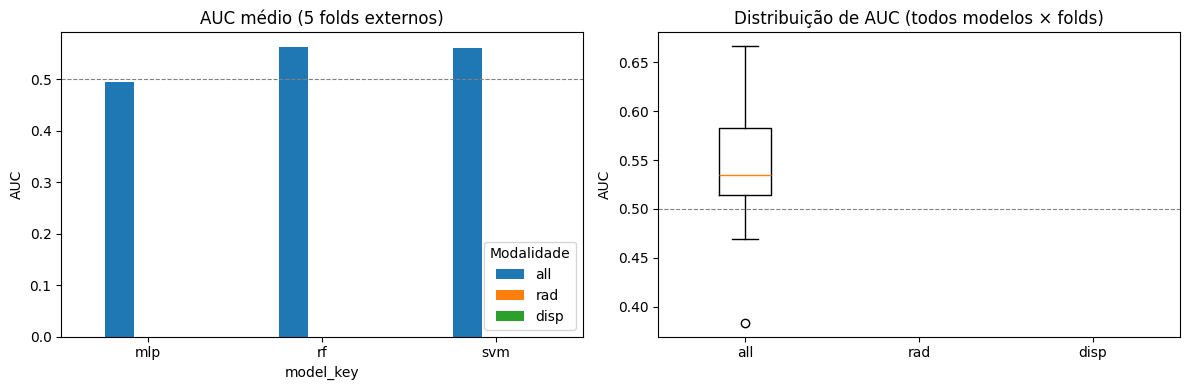

Figura salva em: csvs/abordagem_4_sMCI_pMCI_extremos/ablation_auc_comparison.png


In [28]:
# Comparação visual: AUC por modalidade, modelo e modo de seleção
mod_order = ["all", "rad", "disp"]
has_selection = (
    "selection_mode" in df_ablation.columns
    and df_ablation["selection_mode"].nunique() > 1
)

if has_selection:
    modes = list(dict.fromkeys(df_ablation["selection_mode"]))
    fig, axes = plt.subplots(1, len(modes), figsize=(5 * len(modes), 4), sharey=True)
    if len(modes) == 1:
        axes = [axes]
    for ax, mode in zip(axes, modes):
        sub = df_ablation[df_ablation["selection_mode"] == mode]
        pivot_auc = sub.pivot_table(
            index="model_key", columns="modality", values="auc", aggfunc="mean"
        ).reindex(columns=mod_order)
        pivot_auc.plot(kind="bar", ax=ax, rot=0, legend=(ax is axes[-1]))
        ax.set_title(f"{mode} — {SELECTION_MODES[mode]['label']}")
        ax.set_ylabel("AUC")
        ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    axes[-1].legend(title="Modalidade")
    fig.suptitle("AUC médio (5 folds externos)")
else:
    pivot_auc = df_ablation.pivot_table(
        index="model_key", columns="modality", values="auc", aggfunc="mean"
    ).reindex(columns=mod_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    pivot_auc.plot(kind="bar", ax=axes[0], rot=0)
    axes[0].set_title("AUC médio (5 folds externos)")
    axes[0].set_ylabel("AUC")
    axes[0].legend(title="Modalidade")
    axes[0].axhline(0.5, color="gray", ls="--", lw=0.8)

    data_box = [
        df_ablation.loc[df_ablation["modality"] == m, "auc"].values
        for m in mod_order
    ]
    axes[1].boxplot(data_box, tick_labels=mod_order)
    axes[1].set_title("Distribuição de AUC (todos modelos × folds)")
    axes[1].set_ylabel("AUC")
    axes[1].axhline(0.5, color="gray", ls="--", lw=0.8)

plt.tight_layout()
plt.savefig(BASE_DIR / "ablation_auc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em: {BASE_DIR / 'ablation_auc_comparison.png'}")

In [29]:
# Estabilidade das features selecionadas (frequência por modalidade)
from collections import Counter

def feature_stability(df_mod: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    counter: Counter = Counter()
    for feats_json in df_mod["selected_features"]:
        counter.update(json.loads(feats_json))
    total = len(df_mod)
    rows = [
        {"feature": feat, "count": cnt, "freq": cnt / total}
        for feat, cnt in counter.most_common(top_n)
    ]
    return pd.DataFrame(rows)

for modality in ABLATION_CONFIGS:
    df_mod = df_ablation[df_ablation["modality"] == modality]
    stab = feature_stability(df_mod)
    print(f"\nTop features — {modality.upper()} ({ABLATION_CONFIGS[modality]['label']}):")
    display(stab)


Top features — ALL (merge (rad + disp)):


,feature,count,freq
0,hippocampus_L_d12_ICV_mask_mm3,15,1.0
1,hippocampus_L_d23_ICV_mask_mm3,15,1.0
2,hippocampus_L_d12_csf_norm,15,1.0
3,hippocampus_L_d23_csf_norm,15,1.0
4,hippocampus_L_d12_gm_mm3,15,1.0
5,hippocampus_L_d23_gm_mm3,15,1.0
6,hippocampus_L_d12_gm_norm,15,1.0
7,hippocampus_L_d23_gm_norm,15,1.0
8,hippocampus_L_d12_original_firstorder_10Percen...,15,1.0
9,hippocampus_L_d23_original_firstorder_10Percen...,15,1.0


## Carregar resultados salvos

Se a execução acima já foi feita, use as células abaixo para reanalisar sem re-treinar.

In [30]:
df_ablation = pd.read_csv(RESULTS_PATH)
summary = pd.read_csv(SUMMARY_PATH)
df_ablation.shape, summary.shape

((15, 23), (3, 24))